In [2]:
import pandas as pd
import numpy as np


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Predictive_Maintenance/ai4i2020.csv')

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.shape

(10000, 14)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [11]:
df['Type'].value_counts()

,count
Type,
L,6000
M,2997
H,1003


In [12]:
df['Product ID'].nunique()

10000

In [13]:
df['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [14]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df[failure_modes].sum()

,0
TWF,46
HDF,115
PWF,95
OSF,98
RNF,19


In [15]:
df_clean = df.copy()

In [16]:
df_clean = df_clean.drop(columns=[
    'UDI',
    'Product ID',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
])

In [17]:
df_clean.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure'],
      dtype='object')

In [18]:
df_clean = pd.get_dummies(
    df_clean,
    columns=['Type'],
    drop_first=True,
    dtype=int
)

In [19]:
df_clean.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,1,0
2,298.1,308.5,1498,49.4,5,0,1,0
3,298.2,308.6,1433,39.5,7,0,1,0
4,298.2,308.7,1408,40.0,9,0,1,0


In [20]:
df_clean.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_L', 'Type_M'],
      dtype='object')

In [21]:
df_clean.dtypes

,0
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
Type_L,int64
Type_M,int64


In [22]:
df_clean.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.600000,0.299700
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.489922,0.458149
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,1.000000,0.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,1.000000,1.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000


In [23]:
df_clean['Machine failure'].value_counts(normalize=True) * 100

,proportion
Machine failure,
0,96.61
1,3.39


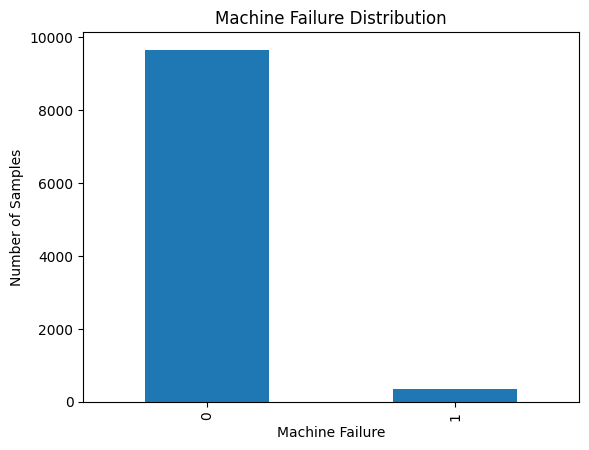

In [24]:
import matplotlib.pyplot as plt

df_clean['Machine failure'].value_counts().plot(kind='bar')
plt.xlabel('Machine Failure')
plt.ylabel('Number of Samples')
plt.title('Machine Failure Distribution')
plt.show()

In [25]:
df_clean.groupby('Machine failure')[[
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


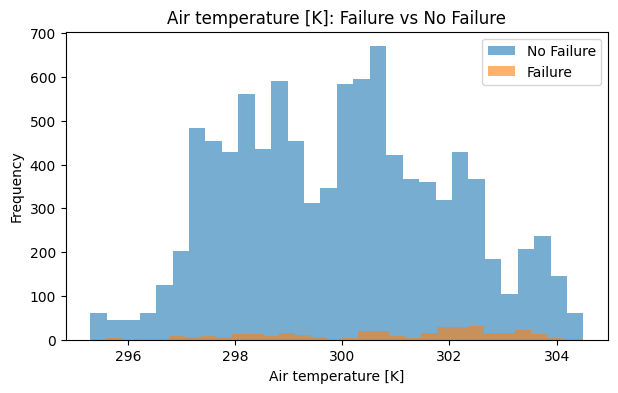

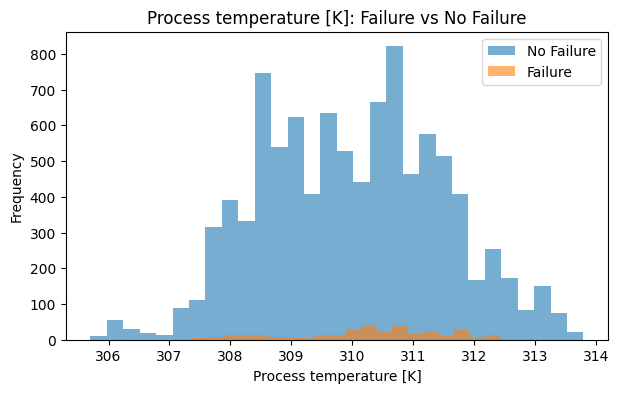

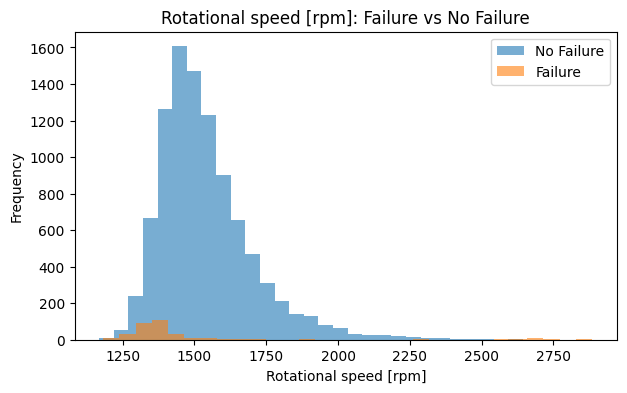

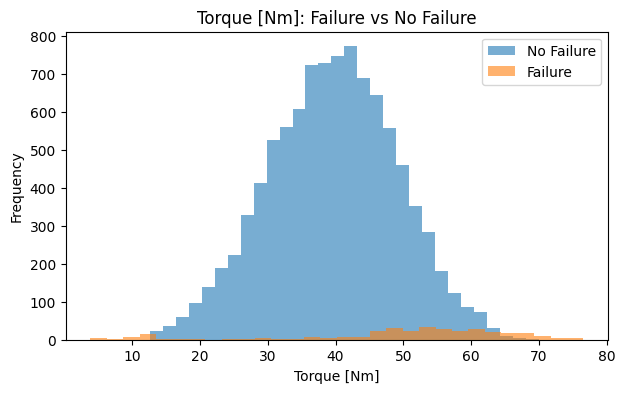

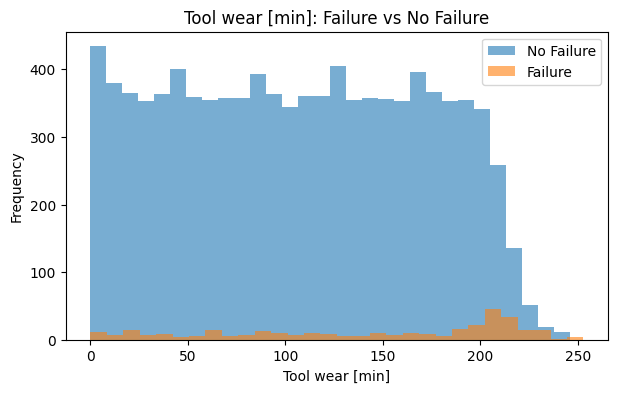

In [26]:
import matplotlib.pyplot as plt

features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for feature in features:
    plt.figure(figsize=(7, 4))

    df_clean[df_clean['Machine failure'] == 0][feature].plot(
        kind='hist',
        bins=30,
        alpha=0.6,
        label='No Failure'
    )

    df_clean[df_clean['Machine failure'] == 1][feature].plot(
        kind='hist',
        bins=30,
        alpha=0.6,
        label='Failure'
    )

    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.title(f'{feature}: Failure vs No Failure')
    plt.legend()
    plt.show()

<Figure size 600x400 with 0 Axes>

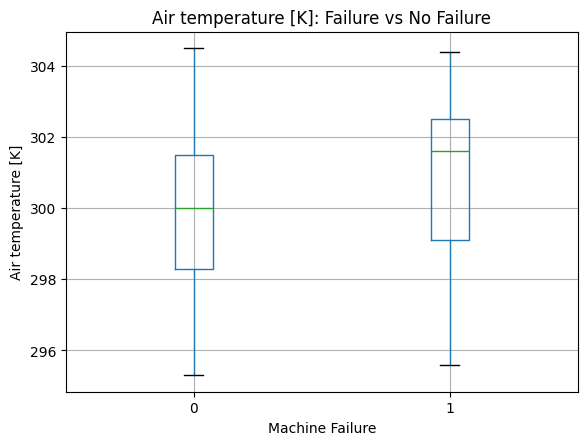

<Figure size 600x400 with 0 Axes>

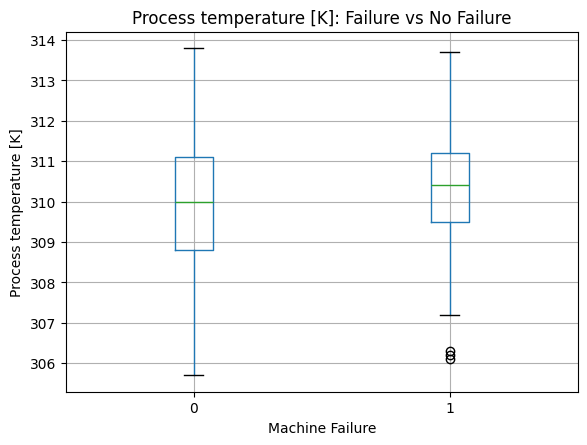

<Figure size 600x400 with 0 Axes>

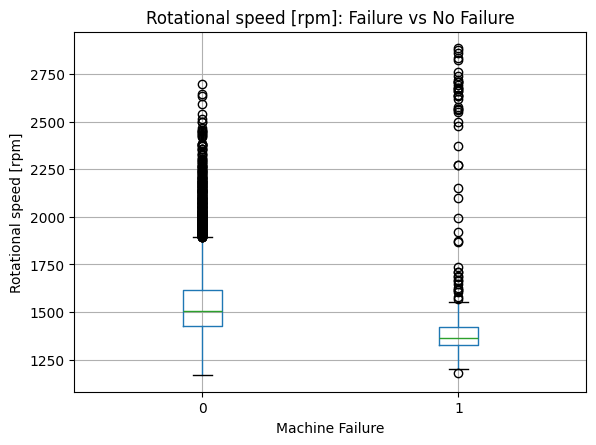

<Figure size 600x400 with 0 Axes>

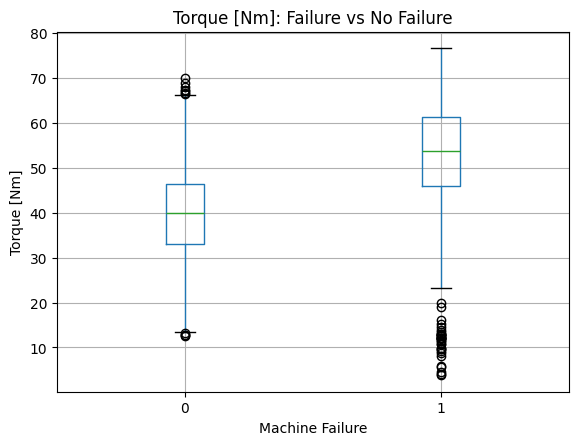

<Figure size 600x400 with 0 Axes>

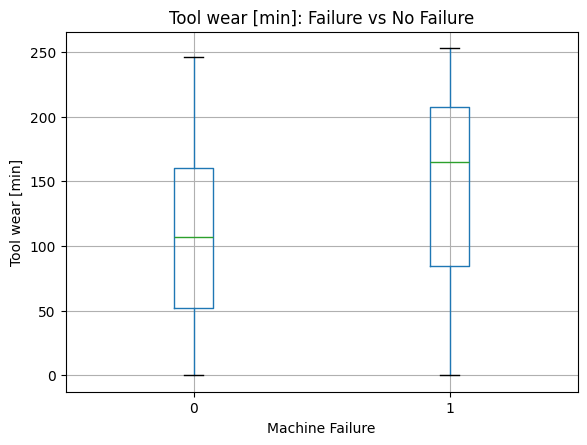

In [27]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for feature in features:
    plt.figure(figsize=(6, 4))

    df_clean.boxplot(
        column=feature,
        by='Machine failure'
    )

    plt.title(f'{feature}: Failure vs No Failure')
    plt.suptitle('')
    plt.xlabel('Machine Failure')
    plt.ylabel(feature)
    plt.show()

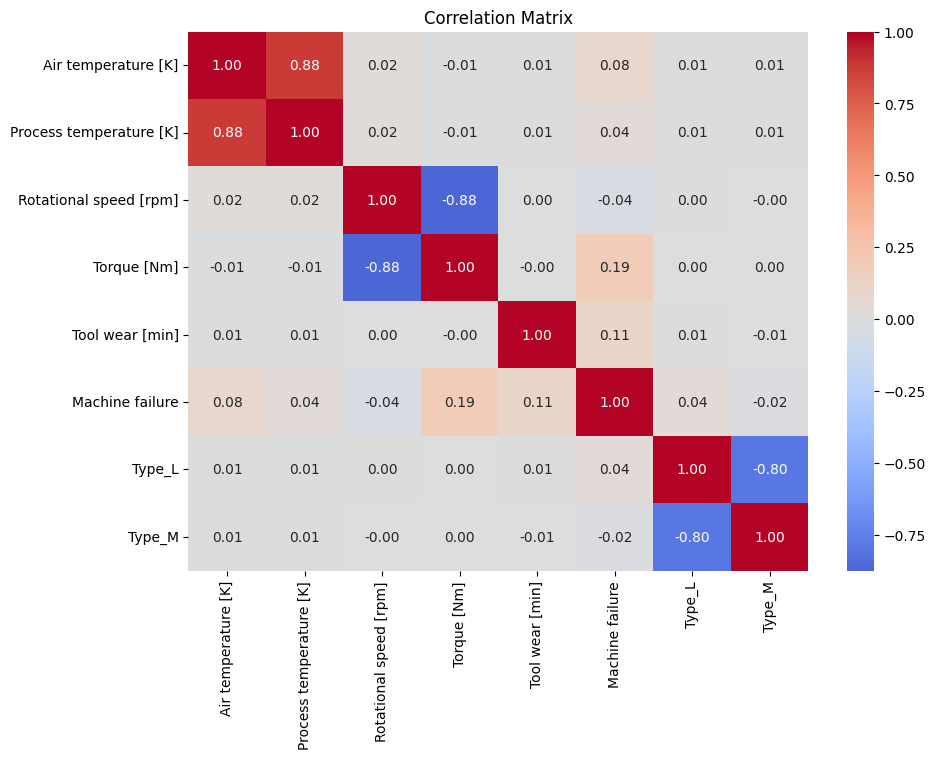

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df_clean.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

In [29]:
df_clean['Temperature difference [K]'] = (
    df_clean['Process temperature [K]']
    - df_clean['Air temperature [K]']
)

In [30]:
df_clean[['Air temperature [K]',
          'Process temperature [K]',
          'Temperature difference [K]']].head()

,Air temperature [K],Process temperature [K],Temperature difference [K]
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [31]:
df_clean['Tool wear [min]'].describe()

,Tool wear [min]
count,10000.000000
mean,107.951000
std,63.654147
min,0.000000
25%,53.000000
50%,108.000000
75%,162.000000
max,253.000000


In [32]:
df_clean['Tool wear level'] = pd.qcut(
    df_clean['Tool wear [min]'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [33]:
df_clean['Tool wear level'].value_counts()

,count
Tool wear level,
Low,3356
Medium,3327
High,3317


In [34]:
df_clean[['Tool wear [min]', 'Tool wear level']].head(10)

,Tool wear [min],Tool wear level
0,0,Low
1,3,Low
2,5,Low
3,7,Low
4,9,Low
5,11,Low
6,14,Low
7,16,Low
8,18,Low
9,21,Low


In [35]:
df_clean.groupby('Tool wear level')['Machine failure'].agg(
    ['count', 'sum', 'mean']
)

/tmp/ipykernel_8277/2267204444.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('Tool wear level')['Machine failure'].agg(


,count,sum,mean
Tool wear level,,,
Low,3356,76,0.022646
Medium,3327,71,0.021341
High,3317,192,0.057884


In [36]:
df_clean['Tool wear level'] = df_clean['Tool wear level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [37]:
df_clean['Tool wear level'].value_counts().sort_index()

,count
Tool wear level,
0,3356
1,3327
2,3317


In [38]:
df_clean.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M,Temperature difference [K],Tool wear level
0,298.1,308.6,1551,42.8,0,0,0,1,10.5,0
1,298.2,308.7,1408,46.3,3,0,1,0,10.5,0
2,298.1,308.5,1498,49.4,5,0,1,0,10.4,0
3,298.2,308.6,1433,39.5,7,0,1,0,10.4,0
4,298.2,308.7,1408,40.0,9,0,1,0,10.5,0


In [39]:
df_clean.columns

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'Type_L', 'Type_M', 'Temperature difference [K]',
       'Tool wear level'],
      dtype='object')

In [40]:
df_clean.groupby(['Type_L', 'Type_M'])['Machine failure'].agg(
    ['count', 'sum', 'mean']
)

count  sum      mean
Type_L Type_M                      
0      0        1003   21  0.020937
       1        2997   83  0.027694
1      0        6000  235  0.039167

In [41]:
df_clean['Machine failure'].value_counts()

,count
Machine failure,
0,9661
1,339


In [42]:
X = df_clean.drop(columns=['Machine failure'])
y = df_clean['Machine failure']

In [43]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 9)
Target shape: (10000,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [45]:
print("Training set:", y_train.value_counts(normalize=True) * 100)
print("Test set:", y_test.value_counts(normalize=True) * 100)

Training set: Machine failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64
Test set: Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [47]:
print("Training shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Training shape: (8000, 9)
Test shape: (2000, 9)


In [48]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(0.51753137533963), np.int64(1): np.float64(14.760147601476016)}


In [49]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Number of folds:", skf.get_n_splits())

Number of folds: 5


In [50]:
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train), 1):
    print(
        f"Fold {fold}: "
        f"Train failure rate = {y_train.iloc[train_idx].mean():.4f}, "
        f"Validation failure rate = {y_train.iloc[val_idx].mean():.4f}"
    )

Fold 1: Train failure rate = 0.0339, Validation failure rate = 0.0338
Fold 2: Train failure rate = 0.0339, Validation failure rate = 0.0338
Fold 3: Train failure rate = 0.0339, Validation failure rate = 0.0338
Fold 4: Train failure rate = 0.0339, Validation failure rate = 0.0338
Fold 5: Train failure rate = 0.0338, Validation failure rate = 0.0344


In [51]:
# Final check before model training

print("Final feature shape:", X_train_scaled.shape)
print("Final target shape:", y_train.shape)

print("\nTraining data:")
print(X_train_scaled.shape)

print("\nTest data:")
print(X_test_scaled.shape)

print("\nTarget distribution:")
print(y_train.value_counts())

Final feature shape: (8000, 9)
Final target shape: (8000,)

Training data:
(8000, 9)

Test data:
(2000, 9)

Target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64


In [52]:
# Save processed datasets for the next ML phase

pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).to_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/X_train_scaled.csv',
    index=False
)

pd.DataFrame(
    X_test_scaled,
    columns=X.columns
).to_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/X_test_scaled.csv',
    index=False
)

y_train.to_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/y_train.csv',
    index=False
)

y_test.to_csv(
    '/content/drive/MyDrive/Predictive_Maintenance/y_test.csv',
    index=False
)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


# Phase 1 Complete — Data Preprocessing

The AI4I 2020 dataset was loaded, inspected, cleaned, transformed, and prepared for machine learning.

### Completed tasks

- Dataset loading and initial inspection
- Missing-value analysis
- Duplicate-value analysis
- Categorical feature encoding
- Feature engineering
- Exploratory data analysis
- Class imbalance analysis
- Train-test split
- Feature scaling
- Class-weight calculation
- Stratified K-Fold validation check

### Final dataset

- Training samples: 8,000
- Testing samples: 2,000
- Features: 9
- Target: Machine failure
- Failure rate: approximately 3.39%

### Output

The processed training and testing datasets have been saved to Google Drive and are ready for the model-training phase.